### Probar modelo con el clasificador

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlp.mlp_main import MLP

In [3]:
# Getting data
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y= data.target

In [4]:
X.shape, y.shape

((150, 4), (150,))

In [5]:
X[:10], y[:10]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [6]:
# Data Wrangling
from sklearn.preprocessing import Normalizer

nrmlzr = Normalizer()
X_nml = nrmlzr.fit_transform(X)

In [7]:
X[:10], y[:10]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [8]:
# Estandarizar media 0 varianza 1
from sklearn.preprocessing import StandardScaler

std_scl = StandardScaler(
    with_mean=True,
    with_std=True
)

X_std = std_scl.fit_transform(X_nml)

In [9]:
# Encoder de Datos
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
y_encoded = ohe.fit_transform(y.reshape(-1, 1))
y_encoded[:10]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [10]:
from sklearn.model_selection import train_test_split

X_test, X_train, y_test, y_train = train_test_split(X_std, y_encoded, test_size=0.2, random_state=42)

In [11]:
# Training model

mlp = MLP(
    layers=[(4, 5, "sigmoid"),(5, 4, "sigmoid"), (4, 3, "softmax")],
    learning_rate=0.05,
)

history = mlp.train(X_train, y_train, epochs=1500, batch_size=32)

Epoch 0, MSE: 0.3496271004628685
Epoch 10, MSE: 0.30346873178905237
Epoch 20, MSE: 0.2840352687818386
Epoch 30, MSE: 0.2610376439699083
Epoch 40, MSE: 0.23673327354425125
Epoch 50, MSE: 0.21475700937898096
Epoch 60, MSE: 0.19727925900630502
Epoch 70, MSE: 0.18431310312745489
Epoch 80, MSE: 0.1747925817312329
Epoch 90, MSE: 0.1675750909877566
Epoch 100, MSE: 0.16178893353346138
Epoch 110, MSE: 0.1568372486131278
Epoch 120, MSE: 0.15231985881623006
Epoch 130, MSE: 0.1479636123873885
Epoch 140, MSE: 0.14357678628462273
Epoch 150, MSE: 0.1390236045589192
Epoch 160, MSE: 0.1342127157742431
Epoch 170, MSE: 0.12909445636155897
Epoch 180, MSE: 0.12366227536469676
Epoch 190, MSE: 0.11795363353233707
Epoch 200, MSE: 0.11204604807616848
Epoch 210, MSE: 0.10604588268189803
Epoch 220, MSE: 0.10007102359820155
Epoch 230, MSE: 0.09423202881928198
Epoch 240, MSE: 0.08861737833512977
Epoch 250, MSE: 0.08328639370412261
Epoch 260, MSE: 0.07826988169479095
Epoch 270, MSE: 0.073575922732747
Epoch 280, MSE

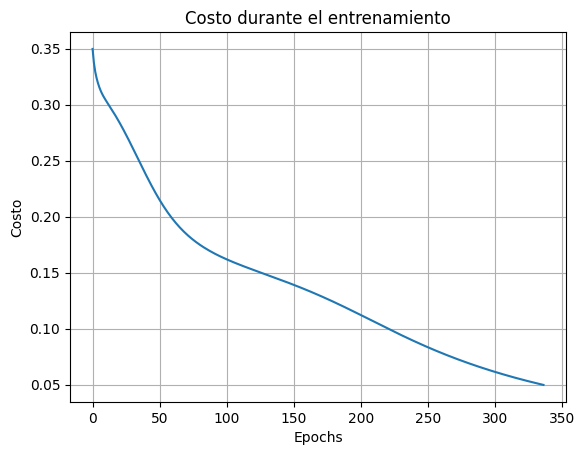

In [12]:
# Graficar funcion de costo

plt.plot(history)
plt.title("Costo durante el entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Costo")
plt.grid()
plt.show()

In [13]:
from sklearn.metrics import classification_report

y_pred = mlp.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        40
           1       0.97      0.88      0.92        41
           2       0.90      0.97      0.94        39

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



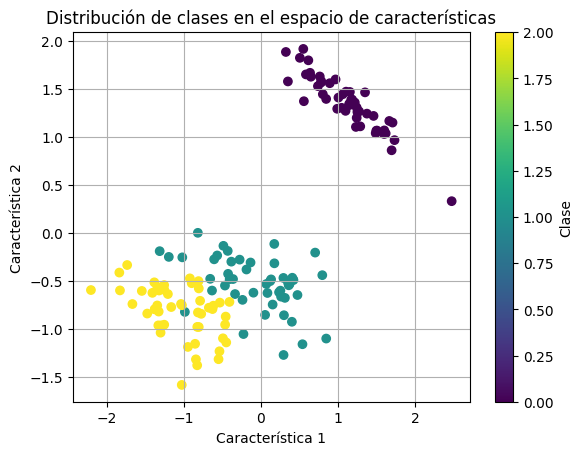

In [14]:
# Graficar distribucion de clases
plt.scatter(X_std[:, 0], X_std[:, 1], c=y, cmap="viridis")
plt.title("Distribución de clases en el espacio de características")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.colorbar(label="Clase")
plt.grid()
plt.show()

In [15]:
# Analisis con las dos primeras caracteristicas 

X_std_2d = X_std[:, :2]

In [16]:
X_std_2d[:10]

array([[1.18437674, 1.39102374],
       [1.73526784, 0.96746359],
       [1.21966217, 1.35970569],
       [1.09974145, 1.27268216],
       [0.89473547, 1.56092823],
       [0.7411829 , 1.53104162],
       [0.64924076, 1.62844696],
       [1.14846823, 1.33285942],
       [1.24432509, 1.20006661],
       [1.50682348, 1.06729926]])

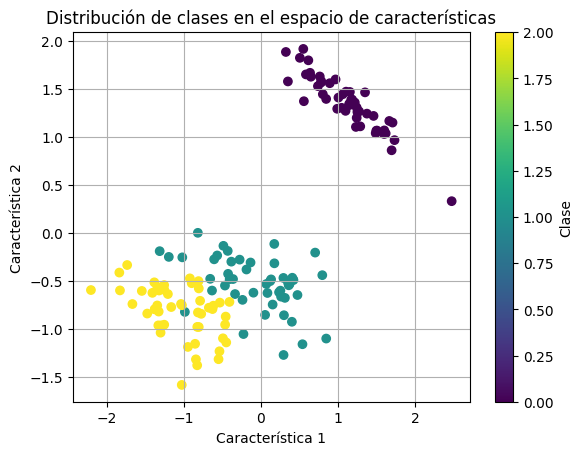

In [17]:
# Graficar distribucion de clases con las dos primeras caracteristicas

plt.scatter(X_std_2d[:, 0], X_std_2d[:, 1], c=y, cmap="viridis")
plt.title("Distribución de clases en el espacio de características")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.colorbar(label="Clase")
plt.grid()
plt.show()

In [19]:
# split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X_std_2d, y_encoded, test_size=0.2, random_state=42)


mlp_2d = MLP(
    layers=[(2, 5, "sigmoid"),(5, 4, "sigmoid"), (4, 3, "softmax")],
    learning_rate=0.05,
)

history_2d = mlp_2d.train(X_train, y_train, epochs=1500, batch_size=32)

Epoch 0, MSE: 0.33802968674762013
Epoch 10, MSE: 0.2666693579433772
Epoch 20, MSE: 0.18952309833410907
Epoch 30, MSE: 0.1560438955462492
Epoch 40, MSE: 0.13418499503133202
Epoch 50, MSE: 0.11398634438519245
Epoch 60, MSE: 0.0960225745215942
Epoch 70, MSE: 0.08124557905703084
Epoch 80, MSE: 0.06960106614146572
Epoch 90, MSE: 0.06060409599250339
Epoch 100, MSE: 0.053657070411810955
Last epoch: 107 with MSE: 0.04972133559685075


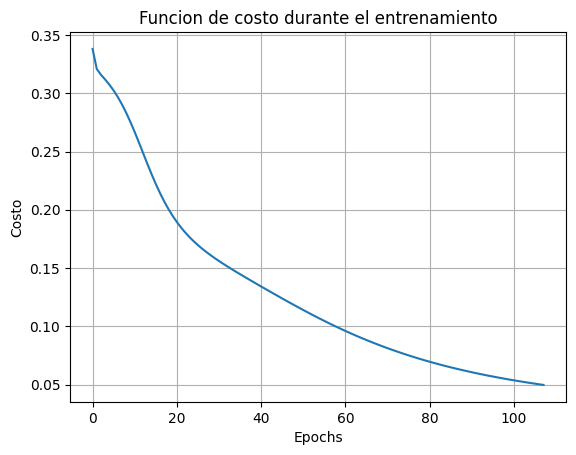

In [20]:
# Graficar funcion de costo

plt.plot(history_2d)
plt.title("Funcion de costo durante el entrenamiento")
plt.xlabel("Epochs")
plt.ylabel("Costo")
plt.grid()
plt.show()

In [21]:
# Test

y_pred = mlp_2d.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print(classification_report(y_test_classes, y_pred_classes))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

